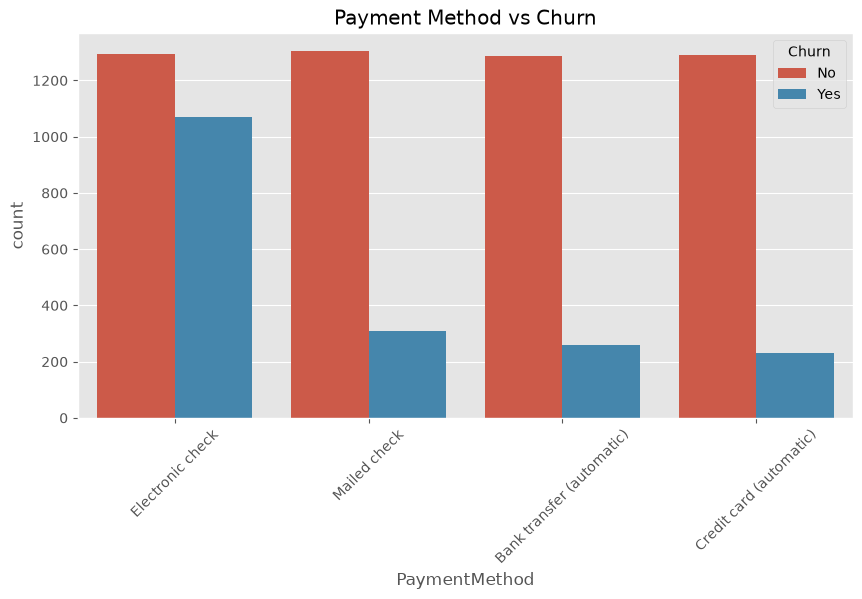

In [162]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)

plt.title('Payment Method vs Churn')

plt.show()

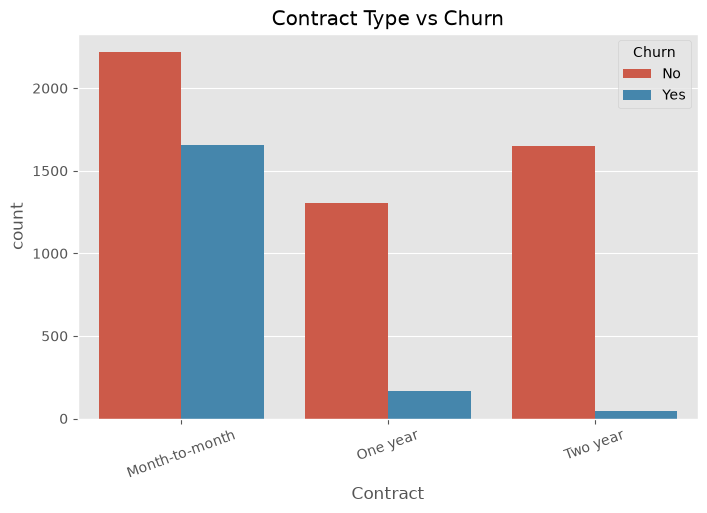

In [161]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Churn')

plt.xticks(rotation=20)

plt.show()

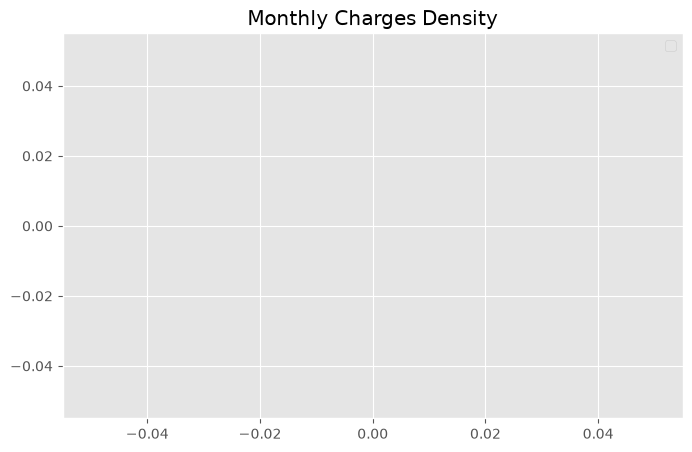

In [160]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df[df['Churn']==0]['MonthlyCharges'],
    label='No Churn',
    fill=True
)

sns.kdeplot(
    df[df['Churn']==1]['MonthlyCharges'],
    label='Churn',
    fill=True
)

plt.title('Monthly Charges Density')

plt.legend()

plt.show()

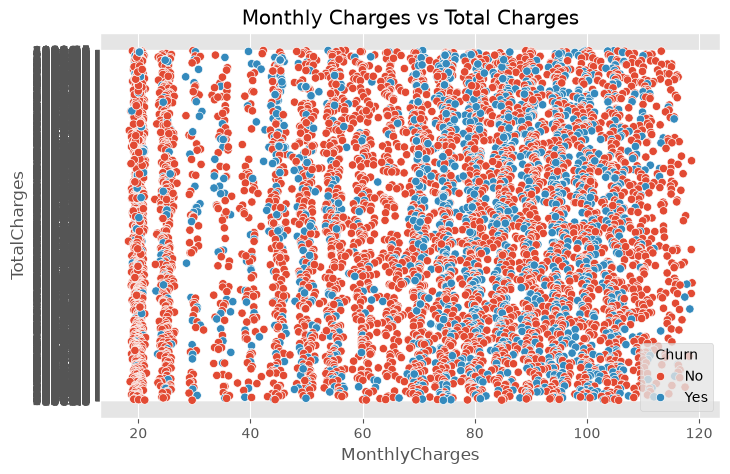

In [157]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    data=df
)

plt.title('Monthly Charges vs Total Charges')

plt.show()

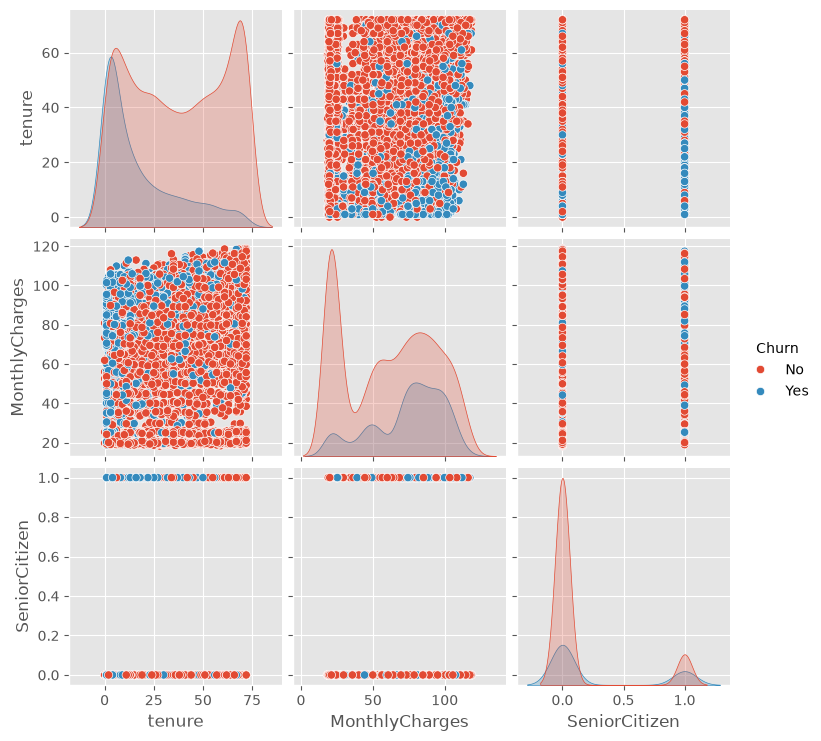

In [156]:
sns.pairplot(
    df_pair[
        ['tenure',
         'MonthlyCharges',
         'TotalCharges',
         'SeniorCitizen',
         'Churn']
    ],
    hue='Churn'
)

plt.show()

In [155]:
df_pair = df.copy()

for col in df_pair.columns:
    if df_pair[col].dtype == 'object':
        df_pair[col] = LabelEncoder().fit_transform(df_pair[col].astype(str))

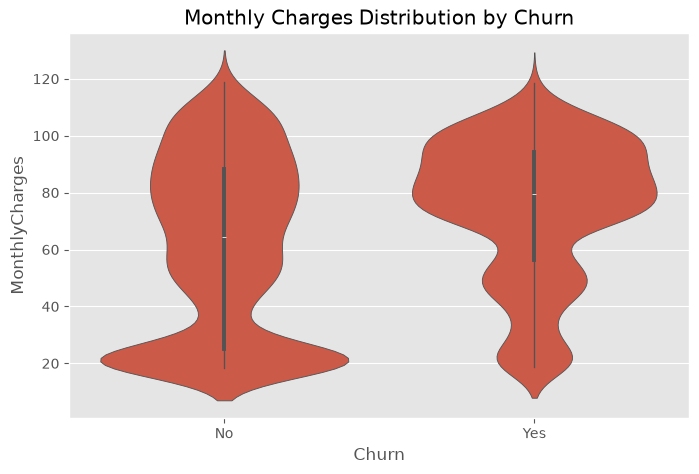

In [154]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges Distribution by Churn')

plt.show()

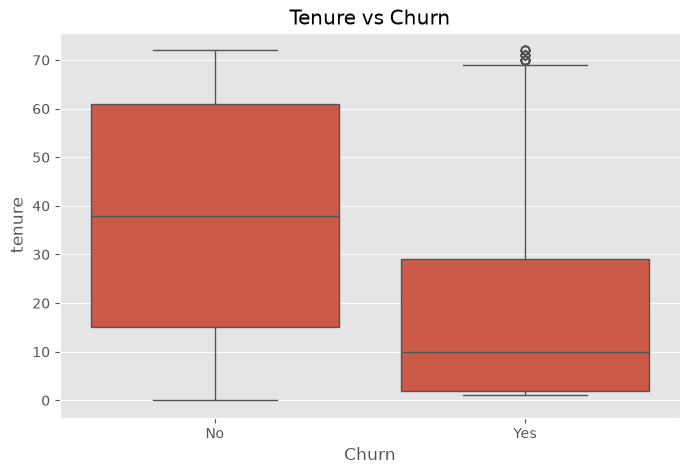

In [153]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Churn')

plt.show()

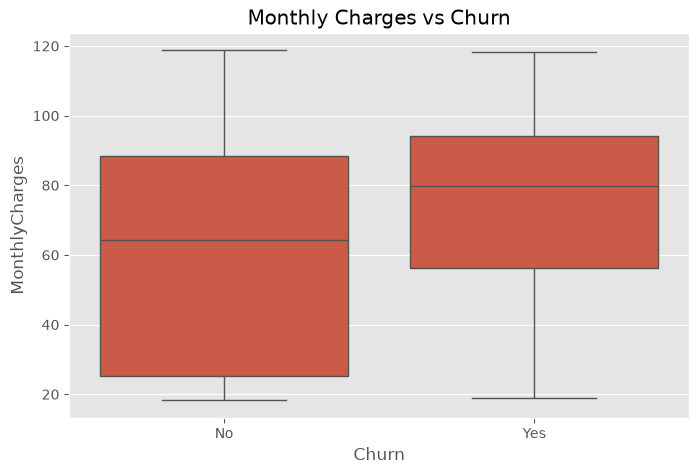

In [152]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')

plt.show()

# Customer Retention Strategies

### 1. Encourage Long-Term Contracts
Month-to-month customers show higher churn rates.

### 2. Reward Loyal Customers
Provide discounts and loyalty programs for customers with long tenure.

### 3. Focus on High-Value Customers
Identify high-value customers at risk and offer personalized plans.

### 4. Improve Customer Support
Enhance technical support and service quality.

### 5. Offer Retention Discounts
Target customers likely to churn with promotional offers.

In [85]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print(contract_churn)

Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


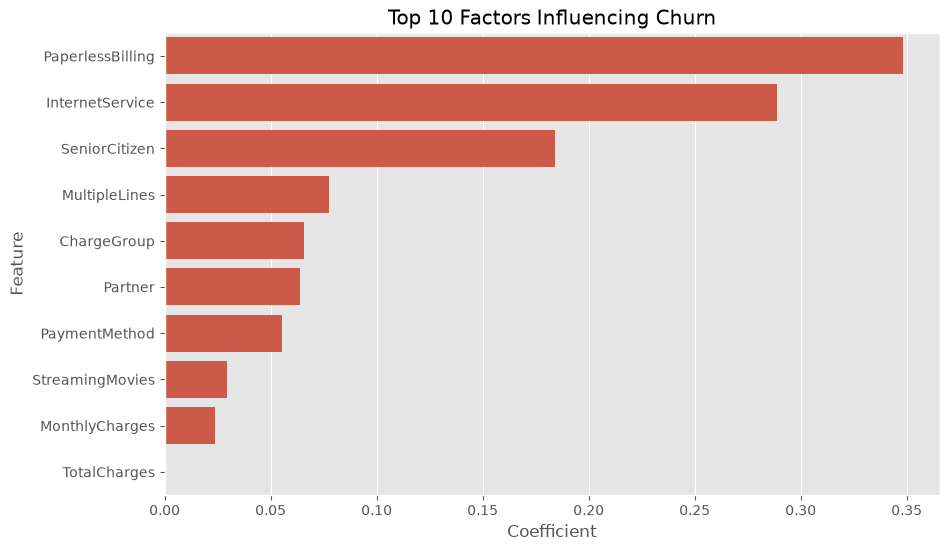

In [86]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top10
)

plt.title('Top 10 Factors Influencing Churn')

plt.show()

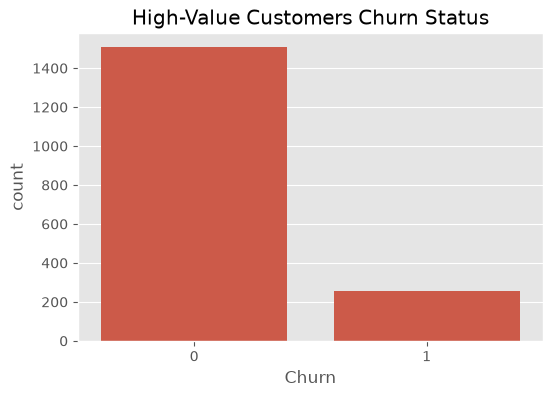

In [87]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=high_value_customers
)

plt.title('High-Value Customers Churn Status')

plt.show()

In [88]:
high_risk_customers = high_value_customers[high_value_customers['Churn'] == 1]

print("High-Value Customers at Risk:", len(high_risk_customers))

High-Value Customers at Risk: 255


In [89]:
high_value_customers = df[df['LTV'] > df['LTV'].quantile(0.75)]

print("Number of High-Value Customers:", len(high_value_customers))

Number of High-Value Customers: 1761


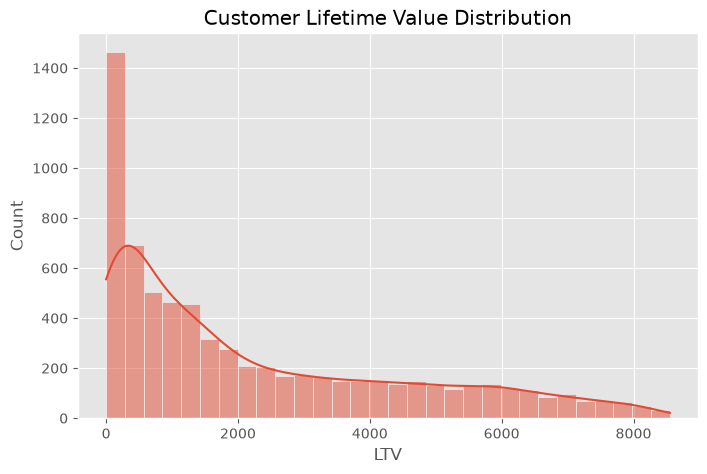

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(df['LTV'], bins=30, kde=True)

plt.title('Customer Lifetime Value Distribution')

plt.show()

In [91]:
# Customer Lifetime Value
df['LTV'] = df['MonthlyCharges'] * df['tenure']

df[['MonthlyCharges','tenure','LTV']].head()

,MonthlyCharges,tenure,LTV
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [92]:
import pickle

with open('../MODELS/Logistic_Regression_Model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [93]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance.head(10))

             Feature  Coefficient
16  PaperlessBilling     0.348115
8    InternetService     0.288612
2      SeniorCitizen     0.184318
7      MultipleLines     0.077368
21       ChargeGroup     0.065520
3            Partner     0.063823
17     PaymentMethod     0.055412
14   StreamingMovies     0.029509
18    MonthlyCharges     0.023737
19      TotalCharges     0.000273


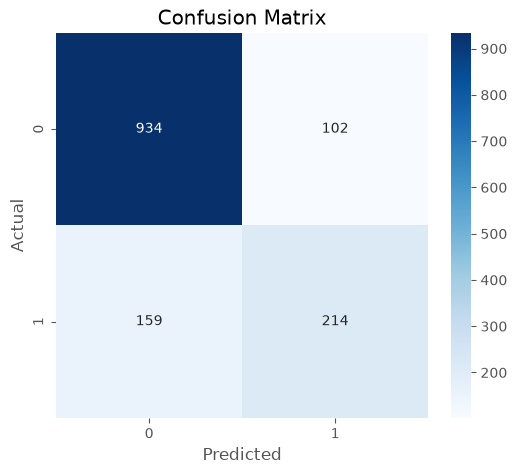

In [94]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [95]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[934 102]
 [159 214]]


In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [97]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8147622427253371


In [98]:
y_pred = model.predict(X_test)

In [99]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [101]:
# Check missing values
print(X.isnull().sum())

# Fill missing values in numerical columns with median
X = X.fillna(X.median(numeric_only=True))

# Fill missing values in categorical columns (if any)
X = X.fillna(0)

# Verify
print(X.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
TenureGroup         0
ChargeGroup         0
dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
TenureGroup         0
ChargeGroup         0
dtype: int64


In [102]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [103]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [104]:
from sklearn.preprocessing import LabelEncoder

# Create a fresh copy
df_model = df.copy()

# Convert category columns to string if they exist
if 'TenureGroup' in df_model.columns:
    df_model['TenureGroup'] = df_model['TenureGroup'].astype(str)

if 'ChargeGroup' in df_model.columns:
    df_model['ChargeGroup'] = df_model['ChargeGroup'].astype(str)

# Convert TotalCharges to numeric
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'].fillna(df_model['TotalCharges'].median(), inplace=True)

# Encode ALL non-numeric columns
le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype != 'int64' and df_model[col].dtype != 'float64':
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# Verify
print(df_model.dtypes)

customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
TenureGroup           int64
ChargeGroup           int64
LTV                 float64
dtype: object


In [105]:
print(df_model.dtypes)

customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
TenureGroup           int64
ChargeGroup           int64
LTV                 float64
dtype: object


In [106]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

In [107]:
print(df_model.dtypes)

customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
TenureGroup           int64
ChargeGroup           int64
LTV                 float64
dtype: object


In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [109]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [110]:
df_model['TotalCharges'] = pd.to_numeric(
    df_model['TotalCharges'],
    errors='coerce'
)

df_model['TotalCharges'].fillna(
    df_model['TotalCharges'].median(),
    inplace=True
)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [111]:
le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

In [112]:
df_model.drop('customerID', axis=1, inplace=True)

In [113]:
df_model = df.copy()

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

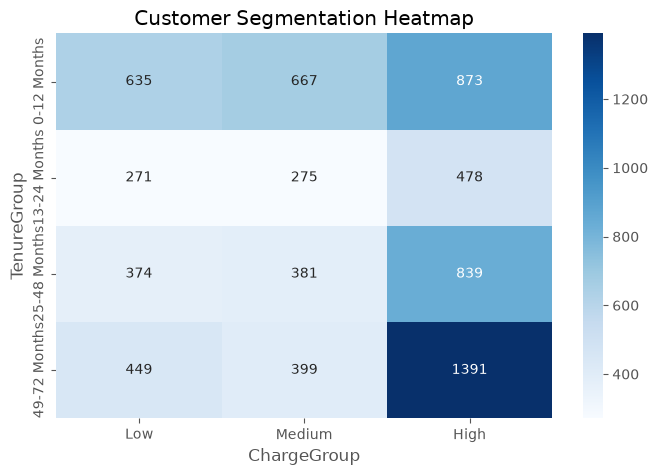

In [115]:
segment_table = pd.crosstab(
    df['TenureGroup'],
    df['ChargeGroup']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    segment_table,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title('Customer Segmentation Heatmap')

plt.show()

In [116]:
charge_churn = pd.crosstab(
    df['ChargeGroup'],
    df['Churn'],
    normalize='index'
)*100

print(charge_churn)

Churn                0          1
ChargeGroup                      
Low          89.106628  10.893372
Medium       76.057971  23.942029
High         64.638571  35.361429


In [117]:
tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
)*100

print(tenure_churn)

Churn                 0          1
TenureGroup                       
0-12 Months   52.321839  47.678161
13-24 Months  71.289062  28.710938
25-48 Months  79.611041  20.388959
49-72 Months  90.486824   9.513176


In [118]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

print(contract_churn)

Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


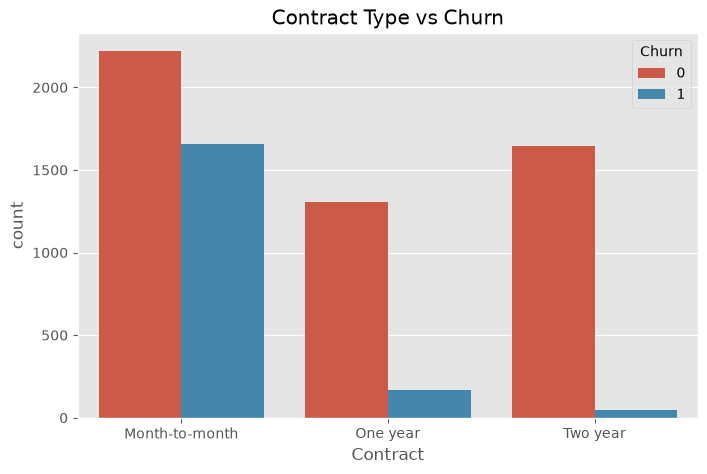

In [119]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Churn')

plt.show()

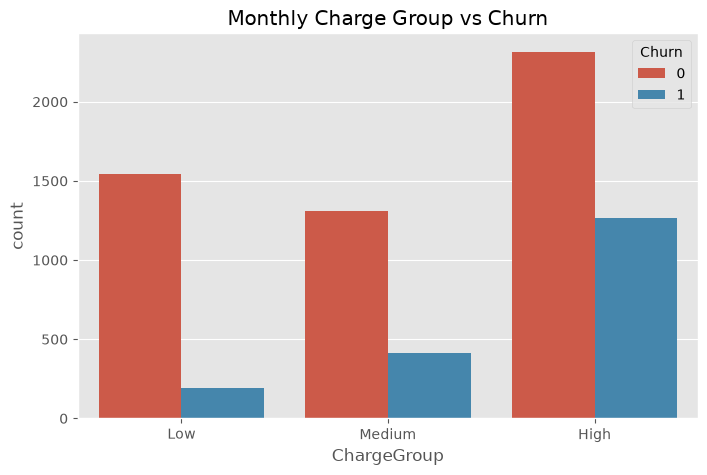

In [120]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='ChargeGroup',
    hue='Churn',
    data=df
)

plt.title('Monthly Charge Group vs Churn')

plt.show()

In [121]:
df['ChargeGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0,35,70,120],
    labels=['Low','Medium','High']
)

df[['MonthlyCharges','ChargeGroup']].head()

,MonthlyCharges,ChargeGroup
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High


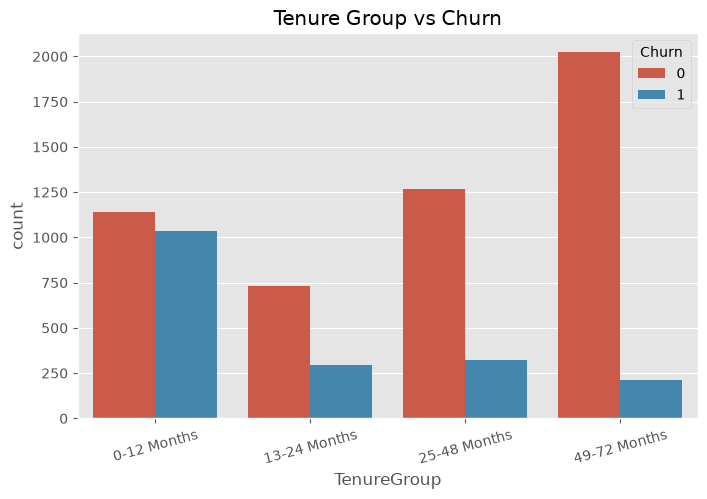

In [122]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='TenureGroup',
    hue='Churn',
    data=df
)

plt.title('Tenure Group vs Churn')
plt.xticks(rotation=15)

plt.show()

In [123]:
# Create tenure groups

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-12 Months','13-24 Months','25-48 Months','49-72 Months']
)

df[['tenure','TenureGroup']].head()

,tenure,TenureGroup
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months


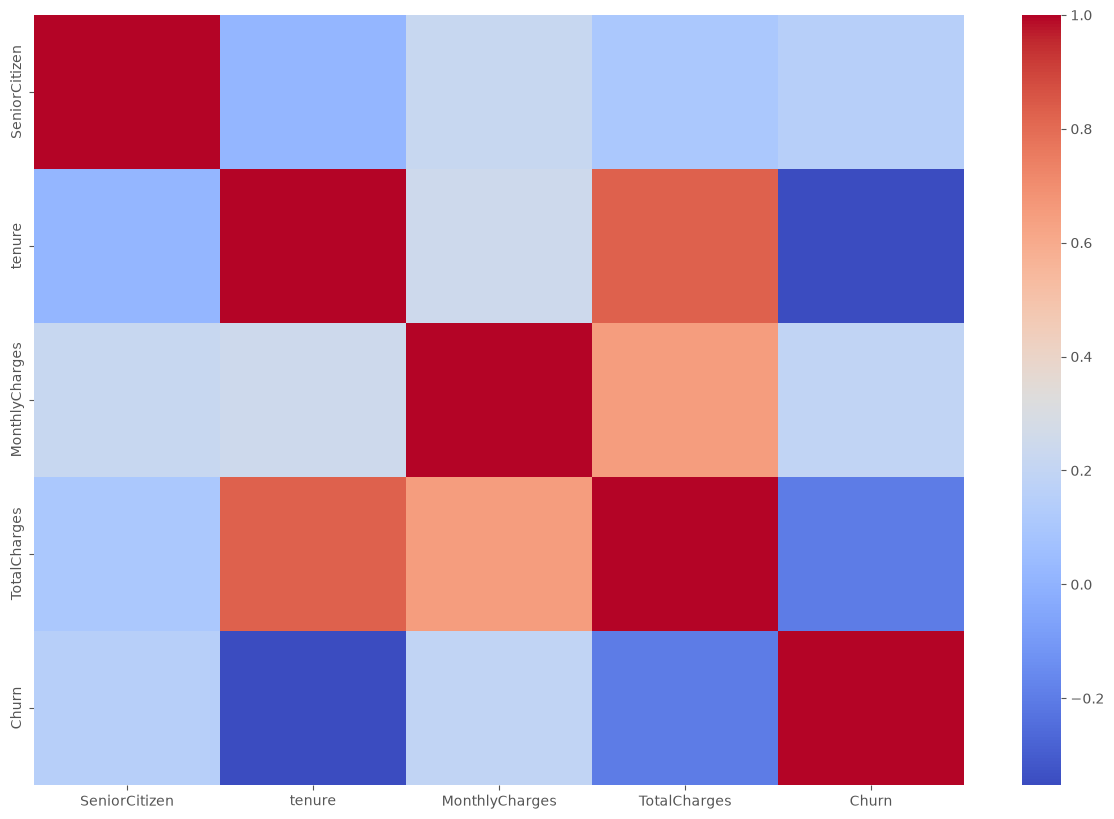

In [124]:
plt.figure(figsize=(15,10))
sns.heatmap(df_heatmap.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show()

In [125]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_heatmap = df.copy()

# Remove customerID because it is unique for every customer
df_heatmap.drop('customerID', axis=1, inplace=True)

# Convert all object columns to numbers
le = LabelEncoder()

for col in df_heatmap.columns:
    if df_heatmap[col].dtype == 'object':
        df_heatmap[col] = le.fit_transform(df_heatmap[col])

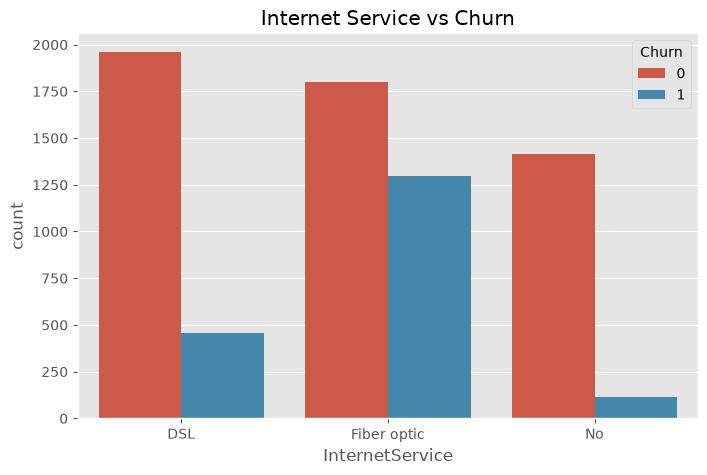

In [126]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service vs Churn')
plt.show()

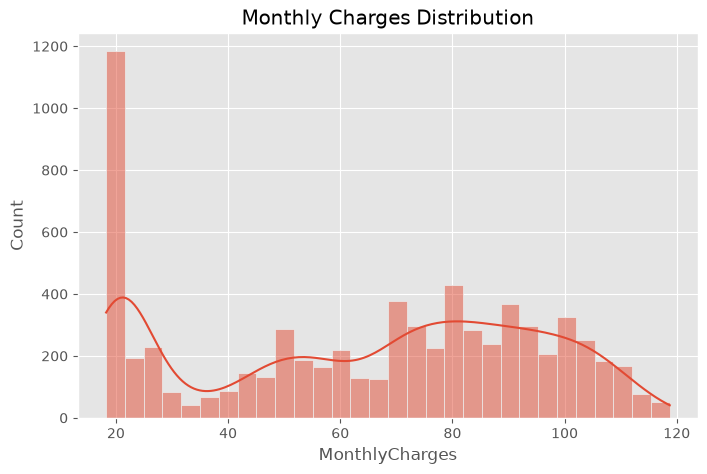

In [127]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title('Monthly Charges Distribution')
plt.show()

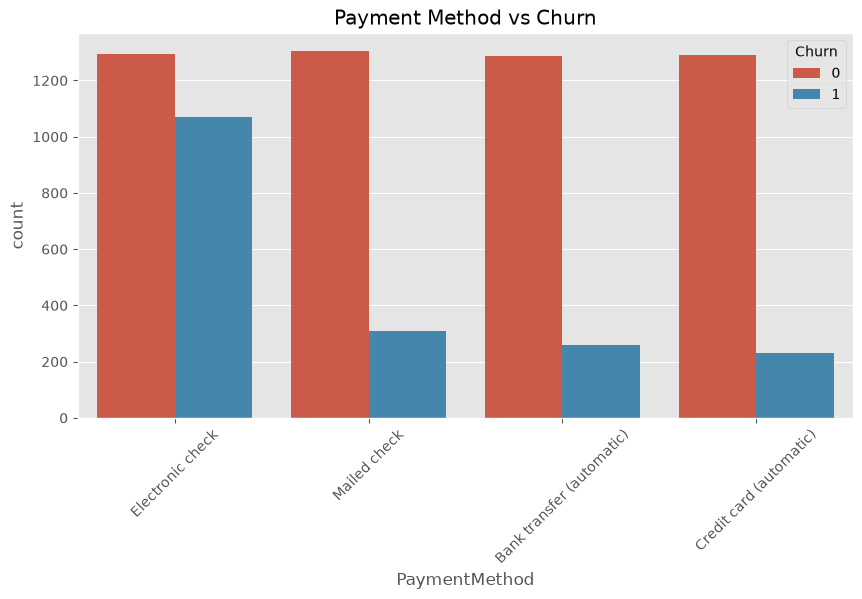

In [128]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title('Payment Method vs Churn')
plt.show()

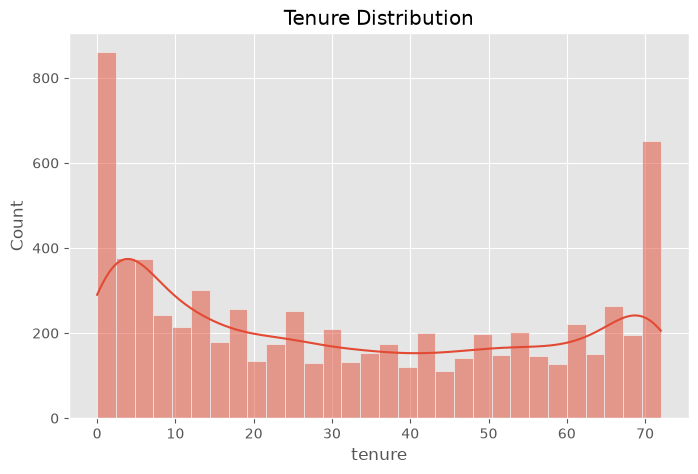

In [129]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title('Tenure Distribution')
plt.show()

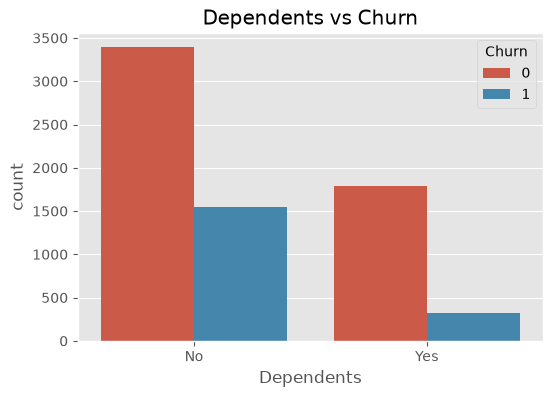

In [130]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.title('Dependents vs Churn')
plt.show()

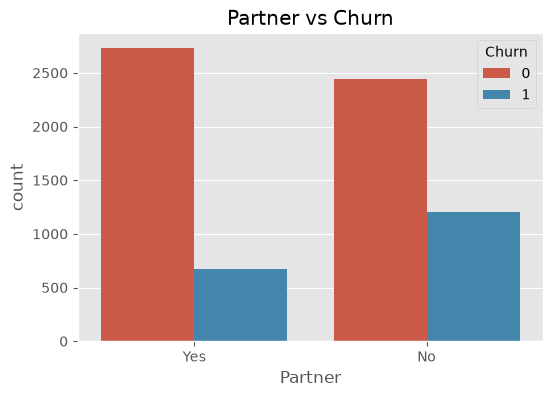

In [131]:
plt.figure(figsize=(6,4))
sns.countplot(x='Partner', hue='Churn', data=df)
plt.title('Partner vs Churn')
plt.show()

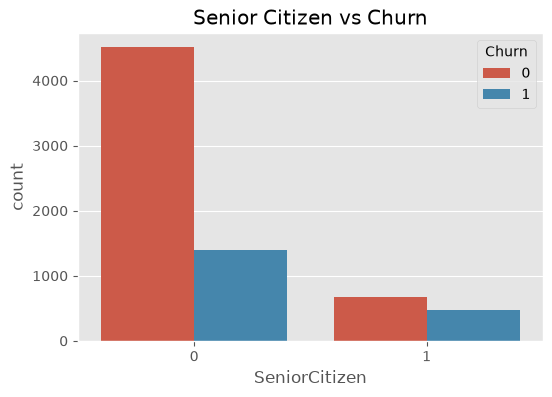

In [132]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Senior Citizen vs Churn')
plt.show()

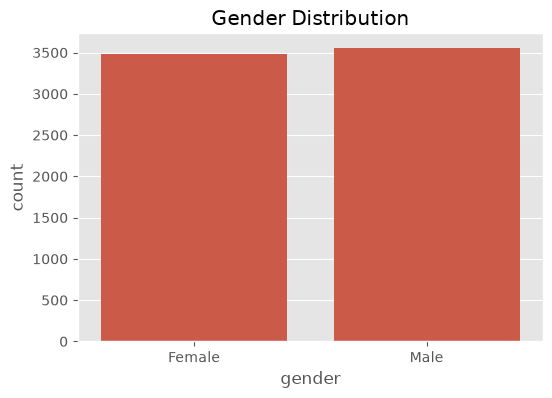

In [133]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

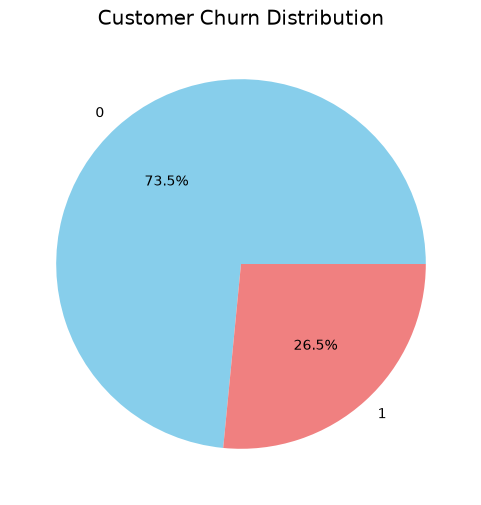

In [134]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','lightcoral']
)
plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

In [135]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [137]:
df.to_csv('../Dataset/Cleaned_Telco_Customer_Churn.csv', index=False)

In [138]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup,LTV
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 Months,Low,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,25-48 Months,Medium,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 Months,Medium,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 Months,Medium,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 Months,High,141.40


In [139]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [140]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [141]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [142]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
Churn               7043
TenureGroup           11
ChargeGroup            0
LTV                    0
dtype: int64

In [143]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [144]:
df.drop_duplicates(inplace=True)

In [145]:
df.duplicated().sum()

np.int64(0)

In [146]:
df.isnull().sum()

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges          11
Churn               7043
TenureGroup           11
ChargeGroup            0
LTV                    0
dtype: int64

In [147]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,LTV
count,7043.000000,7043.000000,7043.000000,7032.000000,0.0,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,NaN,2279.581350
std,0.368612,24.559481,30.090047,2266.771362,NaN,2264.729447
min,0.000000,0.000000,18.250000,18.800000,NaN,0.000000
25%,0.000000,9.000000,35.500000,401.450000,NaN,394.000000
50%,0.000000,29.000000,70.350000,1397.475000,NaN,1393.600000
75%,0.000000,55.000000,89.850000,3794.737500,NaN,3786.100000
max,1.000000,72.000000,118.750000,8684.800000,NaN,8550.000000


In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [149]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChargeGroup,LTV
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN,0-12 Months,Low,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,NaN,25-48 Months,Medium,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,NaN,0-12 Months,Medium,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN,25-48 Months,Medium,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,NaN,0-12 Months,High,141.40


In [150]:
df = pd.read_csv('../Dataset/Telco_Customer_Churn_Dataset.csv')

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
